In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')
print("All imports ready ✅")

All imports ready ✅


In [ ]:
# Load the CarDekho dataset
df = pd.read_csv('cardekho_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (15411, 14)
Columns: ['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])
print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")


Shape after dropping: (15411, 11)
Remaining columns: ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [ ]:
df

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [ ]:
df['fuel_type'].value_counts()

,count
fuel_type,
Petrol,7643
Diesel,7419
CNG,301
LPG,44
Electric,4


In [ ]:
# One-hot encode all categorical columns
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Sample of new columns: {[c for c in df.columns if '_' in c][:10]}")


Shape after encoding: (15411, 45)
Sample of new columns: ['vehicle_age', 'km_driven', 'max_power', 'selling_price', 'brand_BMW', 'brand_Bentley', 'brand_Datsun', 'brand_Ferrari', 'brand_Force', 'brand_Ford']


In [ ]:
df

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,250000,False,False,False,...,False,False,False,False,False,False,False,False,True,True
15407,2,18000,17.50,1373,91.10,7,925000,False,False,False,...,False,False,False,False,False,False,False,False,True,True
15408,6,67000,21.14,1498,103.52,5,425000,False,False,False,...,False,False,False,False,False,True,False,False,False,True
15409,5,3800000,16.00,2179,140.00,7,1225000,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_age                   15411 non-null  int64  
 1   km_driven                     15411 non-null  int64  
 2   mileage                       15411 non-null  float64
 3   engine                        15411 non-null  int64  
 4   max_power                     15411 non-null  float64
 5   seats                         15411 non-null  int64  
 6   selling_price                 15411 non-null  int64  
 7   brand_BMW                     15411 non-null  bool   
 8   brand_Bentley                 15411 non-null  bool   
 9   brand_Datsun                  15411 non-null  bool   
 10  brand_Ferrari                 15411 non-null  bool   
 11  brand_Force                   15411 non-null  bool   
 12  brand_Ford                    15411 non-null  bool   
 13  b

In [ ]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

print(f"Features: {X.shape[0]} rows × {X.shape[1]} columns")
print(f"Target: selling_price — ₹{y.min():,} to ₹{y.max():,}")
print(f"Target mean: ₹{y.mean():,.0f}, median: ₹{y.median():,.0f}")


Features: 15411 rows × 44 columns
Target: selling_price — ₹40,000 to ₹39,500,000
Target mean: ₹774,971, median: ₹556,000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")


Train: 12328 rows (80%)
Test:  3083 rows (20%)


In [ ]:
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [ ]:
X_train

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
11210,0.323969,0.349100,-2.050819,1.756765,2.681685,-0.403824,False,False,False,False,...,False,False,True,False,False,True,False,False,False,False
1347,-1.337798,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
10363,-1.337798,-1.163564,-0.177042,0.893542,3.296910,-0.403824,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
316,0.323969,0.178369,-0.465315,0.024564,0.396229,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
10638,1.321030,0.585469,0.149668,-0.550917,-0.502047,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,0.323969,1.702310,0.248161,-0.453086,-0.270460,2.070500,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
13418,1.653383,0.084198,-0.876105,0.218310,0.066393,-0.403824,False,False,False,False,...,False,True,False,False,False,False,False,False,True,True
5390,0.323969,-0.833967,0.185702,-0.932654,-0.779483,-0.403824,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True
860,-1.337798,-0.951680,-0.273133,-0.550917,-0.432805,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Model trained ✅")
print(f"Number of coefficients: {len(model.coef_)}")
print(f"Intercept: ₹{model.intercept_:,.0f}")

Model trained ✅
Number of coefficients: 44
Intercept: ₹1,324,659


In [ ]:
model.coef_

array([-2.27679116e+05, -4.61441160e+04, -1.61215737e+04,  7.81262973e+04,
        3.35373847e+05,  3.61447730e+04,  4.05858369e+05,  3.66129519e+06,
       -7.09797494e+05,  3.35712157e+07, -6.84161881e+05, -6.05929376e+05,
       -6.34461348e+05, -5.81777427e+05, -5.39248828e+05, -6.72399952e+05,
        3.89829810e+05, -3.30328774e+05, -1.88217266e+05,  1.37973826e+06,
        2.43851701e+06, -3.34953252e+05, -7.57351045e+05, -5.09629233e+05,
        3.05324950e+06, -3.72529030e-09,  2.12192715e+05,  5.81734336e+05,
       -6.92637218e+05,  1.83113118e+06, -6.41815125e+05,  1.83478941e+07,
       -6.76533456e+05, -8.25722441e+05, -4.17293997e+05, -6.20822305e+05,
        1.07324564e+06, -1.20906369e+04, -8.11214717e+04,  4.90755661e+04,
        2.93031384e+05,  2.77714921e+05, -4.11245704e+04, -5.92492214e+04])

In [ ]:
# Predictions on both sets
y_train_pred = model.predict(X_train)
print(y_train_pred)

[3412193.03734085  538816.57194792 3107972.2792696  ...  315413.96838231
  792625.57941124 1096655.71792075]


In [ ]:
print(y_train)

11210    1825000
1347      515000
10363    7500000
316       435000
10638     200000
          ...   
5191      665000
13418     249000
5390      250000
860       620000
7270      960000
Name: selling_price, Length: 12328, dtype: int64


In [ ]:
# Metrics on TRAIN
train_mae = mean_absolute_error(y_train, y_train_pred)
print(train_mae)

199219.72900407415


In [ ]:

y_test_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(test_mae)

212761.44410581293


In [ ]:
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
y_test_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print(test_mae)

669950.2365915277


In [ ]:
df['selling_price'].mean()

np.float64(774971.1164103562)

In [ ]:
df['base_pred'] = 774971.1164103562

In [ ]:
base_mae = mean_absolute_error(df['selling_price'], df['base_pred'])
print(base_mae)

452669.921078294


In [ ]:
train_r2 = r2_score(y_train, y_train_pred)
print(train_r2)

0.8015753782439604


In [ ]:
# Build a coefficient table
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
coef_df

,Feature,Coefficient
0,vehicle_age,-2.276791e+05
1,km_driven,-4.614412e+04
2,mileage,-1.612157e+04
3,engine,7.812630e+04
4,max_power,3.353738e+05
5,seats,3.614477e+04
6,brand_BMW,4.058584e+05
7,brand_Bentley,3.661295e+06
8,brand_Datsun,-7.097975e+05
9,brand_Ferrari,3.357122e+07


In [ ]:
# Build a coefficient table
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print("Top 15 Most Impactful Features (by coefficient magnitude):")
print("=" * 65)
for _, row in coef_df.head(15).iterrows():
    direction = "↑" if row['Coefficient'] > 0 else "↓"
    bar_len = int(row['Abs_Coef'] / coef_df['Abs_Coef'].max() * 30)
    bar = "█" * bar_len
    print(f"  {direction} {row['Feature']:30s} {bar} ({row['Coefficient']:>+12,.0f})")

print(f"\n  Intercept: ₹{model.intercept_:,.0f}")


Top 15 Most Impactful Features (by coefficient magnitude):
  ↑ brand_Ferrari                  ██████████████████████████████ ( +33,571,216)
  ↑ brand_Rolls-Royce              ████████████████ ( +18,347,894)
  ↑ brand_Bentley                  ███ (  +3,661,295)
  ↑ brand_Maserati                 ██ (  +3,053,250)
  ↑ brand_Lexus                    ██ (  +2,438,517)
  ↑ brand_Porsche                  █ (  +1,831,131)
  ↑ brand_Land Rover               █ (  +1,379,738)
  ↑ brand_Volvo                     (  +1,073,246)
  ↓ brand_Tata                      (    -825,722)
  ↓ brand_Mahindra                  (    -757,351)
  ↓ brand_Datsun                    (    -709,797)
  ↓ brand_Nissan                    (    -692,637)
  ↓ brand_Force                     (    -684,162)
  ↓ brand_Skoda                     (    -676,533)
  ↓ brand_Isuzu                     (    -672,400)

  Intercept: ₹1,324,659


In [ ]:
# Pick one car from the test set
sample_idx = X_test.index[0]

In [ ]:
sample_idx

np.int64(3334)

In [ ]:
# Pick one car from the test set
sample_idx = X_test.index[0]
sample_features = X_test.loc[sample_idx]
sample_actual = y_test.loc[sample_idx]

In [ ]:
sample_features

,3334
vehicle_age,1.985737
km_driven,0.413795
mileage,0.149668
engine,-0.550917
max_power,-0.502047
seats,-0.403824
brand_BMW,False
brand_Bentley,False
brand_Datsun,False
brand_Ferrari,False


In [ ]:
sample_actual

np.int64(190000)

In [ ]:
type(X_test)

pandas.core.frame.DataFrame

In [ ]:
X_test

,vehicle_age,km_driven,mileage,engine,max_power,seats,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
3334,1.985737,0.413795,0.149668,-0.550917,-0.502047,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
10928,-0.673091,0.060655,1.838470,-0.453086,-0.616670,-0.403824,False,False,False,False,...,False,False,False,True,False,True,False,False,False,True
2518,0.323969,0.955277,0.248161,-0.453086,-0.271396,2.070500,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
11322,-1.670152,-1.198878,-0.321179,0.026483,0.444184,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
9394,1.653383,0.154826,-0.008882,-1.320145,-1.264645,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1943,0.988676,-0.410198,0.560457,-0.547081,-0.619010,-0.403824,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
10471,-1.337798,-1.116479,-0.393247,-0.547081,-0.272799,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
13098,-1.337798,-1.253027,-0.393247,-0.547081,-0.272799,-0.403824,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
6545,-1.005445,-0.598540,0.185702,-0.932654,-0.779483,-0.403824,False,False,False,False,...,False,False,False,True,False,False,False,False,True,True


In [ ]:
# Method 1: model.predict()
# Pick one car from the test set
sample_idx = X_test.index[0]
sample_features = X_test.loc[sample_idx]
sample_actual = y_test.loc[sample_idx]

# Method 1: model.predict()
sklearn_prediction = model.predict(X_test.loc[[sample_idx]])[0]

print(sklearn_prediction)

-57120.863150607096


In [ ]:
# Manul calcualtion

In [ ]:
sample_features

,3334
vehicle_age,1.985737
km_driven,0.413795
mileage,0.149668
engine,-0.550917
max_power,-0.502047
seats,-0.403824
brand_BMW,False
brand_Bentley,False
brand_Datsun,False
brand_Ferrari,False


In [ ]:
Manual_prediction = 0


contributions = []
for feat, value in sample_features.items():
    coef = model.coef_[list(X_train.columns).index(feat)]
    contribution = coef * value
    contributions.append((feat, value, coef, contribution))

for i in contributions:
    print(i)

('vehicle_age', np.float64(1.9857368532491522), np.float64(-227679.11587518523), np.float64(-452110.8111085394))
('km_driven', np.float64(0.4137954453676014), np.float64(-46144.1160234312), np.float64(-19094.225041009984))
('mileage', np.float64(0.14966790175177855), np.float64(-16121.57370910439), np.float64(-2412.8821099782917))
('engine', np.float64(-0.5509174225989446), np.float64(78126.29726953516), np.float64(-43041.13832893127))
('max_power', np.float64(-0.5020465790486293), np.float64(335373.84695451916), np.float64(-168373.2925658949))
('seats', np.float64(-0.40382371071387335), np.float64(36144.77304341482), np.float64(-14596.116373302553))
('brand_BMW', np.False_, np.float64(405858.3691318681), np.float64(0.0))
('brand_Bentley', np.False_, np.float64(3661295.186986896), np.float64(0.0))
('brand_Datsun', np.False_, np.float64(-709797.4940396062), np.float64(-0.0))
('brand_Ferrari', np.False_, np.float64(33571215.66884778), np.float64(0.0))
('brand_Force', np.False_, np.float6

In [ ]:
len(contributions)

44

In [ ]:
Manual_prediction = 0
for i in contributions:
    Manual_prediction = Manual_prediction + i[3]

Manual_prediction = Manual_prediction + model.intercept_
print(Manual_prediction)

-57120.863150607096


In [ ]:
# Pick one car from the test set
sample_idx = X_test.index[0]
sample_features = X_test.loc[sample_idx]
sample_actual = y_test.loc[sample_idx]

# Method 1: model.predict()
sklearn_prediction = model.predict(X_test.loc[[sample_idx]])[0]

# Method 2: Manual calculation
manual_prediction = 0.0
print("Manual Prediction Breakdown:")
print("=" * 70)

# Show the top contributing features (non-zero ones)
contributions = []
for feat, val in sample_features.items():
    coef = model.coef_[list(X_train.columns).index(feat)]
    contribution = coef * val
    contributions.append((feat, val, coef, contribution))

# Sort by absolute contribution
contributions.sort(key=lambda x: abs(x[3]), reverse=True)

# Show top 10 contributors
for feat, val, coef, contrib in contributions[:10]:
    manual_prediction += contrib
    print(f"  {feat:30s}  value={val:>8.3f} × coef={coef:>12,.0f} = ₹{contrib:>12,.0f}")

# Add remaining features
remaining = sum(c[3] for c in contributions[10:])
manual_prediction += remaining
print(f"  {'(remaining features)':30s}  {'':>8s}   {'':>12s}   ₹{remaining:>12,.0f}")

# Add intercept
manual_prediction += model.intercept_
print(f"  {'+ Intercept':30s}  {'':>8s}   {'':>12s}   ₹{model.intercept_:>12,.0f}")
print("=" * 70)
print(f"  Manual prediction:   ₹{manual_prediction:>12,.0f}")
print(f"  sklearn prediction:  ₹{sklearn_prediction:>12,.0f}")
print(f"  Actual price:        ₹{sample_actual:>12,.0f}")
print(f"  Error:               ₹{abs(sample_actual - sklearn_prediction):>12,.0f}")
print(f"\n  Match? {abs(manual_prediction - sklearn_prediction) < 1}  ✅")


Manual Prediction Breakdown:
  brand_Hyundai                   value=   1.000 × coef=    -581,777 = ₹    -581,777
  vehicle_age                     value=   1.986 × coef=    -227,679 = ₹    -452,111
  max_power                       value=  -0.502 × coef=     335,374 = ₹    -168,373
  transmission_type_Manual        value=   1.000 × coef=     -59,249 = ₹     -59,249
  engine                          value=  -0.551 × coef=      78,126 = ₹     -43,041
  fuel_type_Petrol                value=   1.000 × coef=     -41,125 = ₹     -41,125
  km_driven                       value=   0.414 × coef=     -46,144 = ₹     -19,094
  seats                           value=  -0.404 × coef=      36,145 = ₹     -14,596
  mileage                         value=   0.150 × coef=     -16,122 = ₹      -2,413
  brand_BMW                       value=   0.000 × coef=     405,858 = ₹           0
  (remaining features)                                      ₹           0
  + Intercept                                  

# Regularisaiton


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

print('All imports ready ✅')

All imports ready ✅


In [ ]:
# Load
df = pd.read_csv('cardekho_dataset.csv')
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])

# One-hot encode
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

# Separate features and target
X = df.drop(columns=['selling_price'])
y = df['selling_price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} rows')
print('Data prep complete ✅')

Train: 12328 rows, 44 features
Test:  3083 rows
Data prep complete ✅


In [ ]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

ols_train_mae = mean_absolute_error(y_train, y_train_pred)
ols_test_mae = mean_absolute_error(y_test, y_test_pred)
ols_train_r2 = r2_score(y_train, y_train_pred)
ols_test_r2 = r2_score(y_test, y_test_pred)

print('=' * 55)
print(f'{"OLS Baseline":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(ols_train_mae):>15} {"₹{:,.0f}".format(ols_test_mae):>15}')
print(f'{"R²":<15} {ols_train_r2:>15.4f} {ols_test_r2:>15.4f}')
print('=' * 55)
gap = ols_train_r2 - ols_test_r2
print(f'\nTrain-Test Gap (R²): {gap:.4f}')
print('→ Overfitting detected!' if gap > 0.05 else '→ Gap is small.')

OLS Baseline              Train            Test
MAE                    ₹199,220        ₹212,761
R²                       0.8016          0.7360

Train-Test Gap (R²): 0.0656
→ Overfitting detected!


In [ ]:
ridge_default = Ridge(alpha=1.0)
ridge_default.fit(X_train, y_train)

y_tr = ridge_default.predict(X_train)
y_te = ridge_default.predict(X_test)

print('=' * 55)
print(f'{"Ridge (α=1.0)":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
print('=' * 55)

Ridge (α=1.0)             Train            Test
MAE                    ₹210,894        ₹220,956
R²                       0.7642          0.7366


In [ ]:
ridge_default = Ridge(alpha=0.10)
ridge_default.fit(X_train, y_train)

y_tr = ridge_default.predict(X_train)
y_te = ridge_default.predict(X_test)

print('=' * 55)
print(f'{"Ridge (α=1.0)":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
print('=' * 55)

Ridge (α=1.0)             Train            Test
MAE                    ₹200,942        ₹213,834
R²                       0.8003          0.7368


In [ ]:
ridge_default = Ridge(alpha=0.20)
ridge_default.fit(X_train, y_train)

y_tr = ridge_default.predict(X_train)
y_te = ridge_default.predict(X_test)

print('=' * 55)
print(f'{"Ridge (α=1.0)":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
print('=' * 55)

Ridge (α=1.0)             Train            Test
MAE                    ₹202,536        ₹214,866
R²                       0.7972          0.7372


In [ ]:
alphas = [0.001, 0.01, 0.1, 1,5,7,9,  10, 50, 100, 500, 1000, 5000, 10000]

r2_values = []
mae_values = []
for i in alphas:
    print("=" *80)
    print(" ")
    print(f"Alpha value is set to {i}")
    print(" ")
    ridge_default = Ridge(alpha=i)
    ridge_default.fit(X_train, y_train)

    y_tr = ridge_default.predict(X_train)
    y_te = ridge_default.predict(X_test)
    r2_values.append((r2_score(y_train, y_tr),r2_score(y_test, y_te)))
    mae_values.append((mean_absolute_error(y_train, y_tr),mean_absolute_error(y_test, y_te)))
    print('=' * 55)
    print(f'{"Ridge (α=1.0)":<15} {"Train":>15} {"Test":>15}')
    print('=' * 55)
    print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
    print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
    print('=' * 55)

 
Alpha value is set to 0.001
 
Ridge (α=1.0)             Train            Test
MAE                    ₹199,237        ₹212,772
R²                       0.8016          0.7360
 
Alpha value is set to 0.01
 
Ridge (α=1.0)             Train            Test
MAE                    ₹199,396        ₹212,865
R²                       0.8016          0.7361
 
Alpha value is set to 0.1
 
Ridge (α=1.0)             Train            Test
MAE                    ₹200,942        ₹213,834
R²                       0.8003          0.7368
 
Alpha value is set to 1
 
Ridge (α=1.0)             Train            Test
MAE                    ₹210,894        ₹220,956
R²                       0.7642          0.7366
 
Alpha value is set to 5
 
Ridge (α=1.0)             Train            Test
MAE                    ₹222,752        ₹230,954
R²                       0.7016          0.7300
 
Alpha value is set to 7
 
Ridge (α=1.0)             Train            Test
MAE                    ₹225,005        ₹233,121
R²     

In [ ]:
r2_values

[(0.8015752177387906, 0.7360048429742212),
 (0.8015596343343796, 0.7360923974619396),
 (0.8002645991170927, 0.7367581381647789),
 (0.7642428859972742, 0.7365715780232368),
 (0.7016458055723211, 0.7300497891234892),
 (0.691448778191177, 0.7278237428876811),
 (0.6848795880673971, 0.7259271119878986),
 (0.6823736218091636, 0.7250696356897082),
 (0.6565193729631132, 0.7083590759966416),
 (0.6495822200580555, 0.7008184131423187),
 (0.6371075771934356, 0.686419561264501),
 (0.6302664446411537, 0.6792817911994111),
 (0.5862072770718285, 0.6349410160533615),
 (0.5353743513926584, 0.5829697312171597)]

In [ ]:
mae_values

[(199237.40131409984, 212771.8477187927),
 (199395.8274613738, 212865.4581578076),
 (200942.21809674246, 213833.9183893717),
 (210894.2401364595, 220956.15996696084),
 (222752.45321613076, 230953.96208285735),
 (225004.97803404793, 233121.0459888411),
 (226649.3557219769, 234716.15280825822),
 (227334.05622957065, 235386.76632939745),
 (237007.57922913408, 246004.32646909458),
 (240246.19007474597, 249676.3563679093),
 (242940.9989130217, 252852.7367249419),
 (240577.3820743608, 250771.12322596987),
 (228742.47814714877, 240084.1030655267),
 (232254.3610691721, 245316.43082249802)]

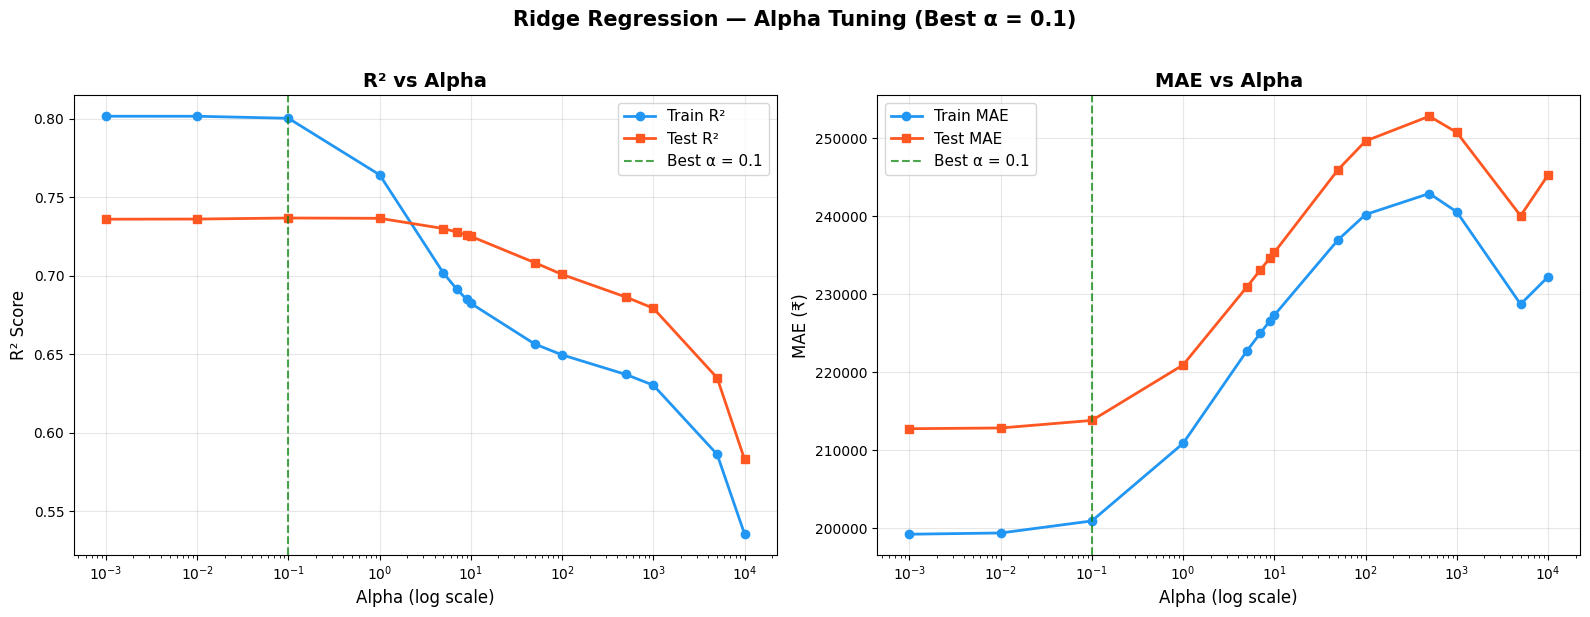

In [ ]:
# ── Alpha Tuning Curves ──

import matplotlib.pyplot as plt
import numpy as np

alphas = [0.001, 0.01, 0.1, 1, 5, 7, 9, 10, 50, 100, 500, 1000, 5000, 10000]

r2_values = []
mae_values = []

for i in alphas:
    ridge = Ridge(alpha=i)
    ridge.fit(X_train, y_train)
    y_tr = ridge.predict(X_train)
    y_te = ridge.predict(X_test)
    r2_values.append((r2_score(y_train, y_tr), r2_score(y_test, y_te)))
    mae_values.append((mean_absolute_error(y_train, y_tr), mean_absolute_error(y_test, y_te)))

r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

# Find best alpha (highest test R²)
best_idx = np.argmax(r2_test)
best_alpha = alphas[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── R² Plot ──
axes[0].plot(alphas, r2_train, 'o-', label='Train R²', color='#2196F3', linewidth=2)
axes[0].plot(alphas, r2_test, 's-', label='Test R²', color='#FF5722', linewidth=2)
axes[0].axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── MAE Plot ──
axes[1].plot(alphas, mae_train, 'o-', label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(alphas, mae_test, 's-', label='Test MAE', color='#FF5722', linewidth=2)
axes[1].axvline(best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {best_alpha}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('MAE (₹)', fontsize=12)
axes[1].set_title('MAE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ridge Regression — Alpha Tuning (Best α = {best_alpha})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
r2_train, r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

# Find best alpha (highest test R²)
best_idx = np.argmax(r2_train)
best_alpha = alphas[best_idx]
print(best_alpha)

0.001


# Training the best model

In [ ]:
best_ridge_model = Ridge(alpha=1)
best_ridge_model.fit(X_train, y_train)


models = {
    'OLS': ols_model,
    f"Ridge (α=1)": best_ridge_model,
}

print('=' * 70)
print(f'{"Model":<25} {"Train MAE":>12} {"Test MAE":>12} {"Train R²":>10} {"Test R²":>10}')
print('=' * 70)

for name, model in models.items():
    tr_p = model.predict(X_train)
    te_p = model.predict(X_test)
    print(f'{name:<25} {"₹{:,.0f}".format(mean_absolute_error(y_train, tr_p)):>12} '
          f'{"₹{:,.0f}".format(mean_absolute_error(y_test, te_p)):>12} '
          f'{r2_score(y_train, tr_p):>10.4f} {r2_score(y_test, te_p):>10.4f}')

print('=' * 70)

Model                        Train MAE     Test MAE   Train R²    Test R²
OLS                           ₹199,220     ₹212,761     0.8016     0.7360
Ridge (α=1)                   ₹210,894     ₹220,956     0.7642     0.7366


In [ ]:
ols_model.coef_

array([-2.27679116e+05, -4.61441160e+04, -1.61215737e+04,  7.81262973e+04,
        3.35373847e+05,  3.61447730e+04,  4.05858369e+05,  3.66129519e+06,
       -7.09797494e+05,  3.35712157e+07, -6.84161881e+05, -6.05929376e+05,
       -6.34461348e+05, -5.81777427e+05, -5.39248828e+05, -6.72399952e+05,
        3.89829810e+05, -3.30328774e+05, -1.88217266e+05,  1.37973826e+06,
        2.43851701e+06, -3.34953252e+05, -7.57351045e+05, -5.09629233e+05,
        3.05324950e+06, -3.72529030e-09,  2.12192715e+05,  5.81734336e+05,
       -6.92637218e+05,  1.83113118e+06, -6.41815125e+05,  1.83478941e+07,
       -6.76533456e+05, -8.25722441e+05, -4.17293997e+05, -6.20822305e+05,
        1.07324564e+06, -1.20906369e+04, -8.11214717e+04,  4.90755661e+04,
        2.93031384e+05,  2.77714921e+05, -4.11245704e+04, -5.92492214e+04])

In [ ]:
best_ridge_model.coef_

array([-2.21029750e+05, -4.66926414e+04,  4.31312736e+03,  8.34841969e+04,
        4.32270222e+05,  1.94610242e+04,  1.79505504e+05,  1.88624511e+06,
       -6.58614893e+05,  1.62284481e+07, -3.24740861e+05, -6.14375758e+05,
       -6.76473914e+05, -5.94451338e+05, -4.18095272e+05, -6.26610792e+05,
        1.75555758e+05, -4.77985032e+05, -2.38614221e+05,  1.15731679e+06,
        1.88255398e+06, -4.18774052e+05, -7.32888013e+05, -4.92354273e+05,
        1.78293831e+06,  0.00000000e+00, -4.62270871e+03,  4.39031061e+05,
       -6.86697424e+05,  1.28579252e+06, -6.19407807e+05,  8.62496665e+06,
       -7.35087474e+05, -8.53429343e+05, -4.37636912e+05, -6.20763464e+05,
        8.50761488e+05, -5.28716700e+03, -8.76743018e+04,  9.62317197e+03,
        1.19464551e+05,  3.03127272e+05, -3.86133029e+04, -3.01140111e+04])

In [ ]:
X_train.columns

Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'brand_BMW', 'brand_Bentley', 'brand_Datsun', 'brand_Ferrari',
       'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai',
       'brand_ISUZU', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia',
       'brand_Land Rover', 'brand_Lexus', 'brand_MG', 'brand_Mahindra',
       'brand_Maruti', 'brand_Maserati', 'brand_Mercedes-AMG',
       'brand_Mercedes-Benz', 'brand_Mini', 'brand_Nissan', 'brand_Porsche',
       'brand_Renault', 'brand_Rolls-Royce', 'brand_Skoda', 'brand_Tata',
       'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG',
       'fuel_type_Petrol', 'transmission_type_Manual'],
      dtype='object')

In [ ]:
coef_comparison = pd.DataFrame({
    "Feature" : X_train.columns,
    "OLS" : ols_model.coef_,
    "Ridge" : best_ridge_model.coef_

})

coef_comparison

,Feature,OLS,Ridge
0,vehicle_age,-2.276791e+05,-2.210297e+05
1,km_driven,-4.614412e+04,-4.669264e+04
2,mileage,-1.612157e+04,4.313127e+03
3,engine,7.812630e+04,8.348420e+04
4,max_power,3.353738e+05,4.322702e+05
5,seats,3.614477e+04,1.946102e+04
6,brand_BMW,4.058584e+05,1.795055e+05
7,brand_Bentley,3.661295e+06,1.886245e+06
8,brand_Datsun,-7.097975e+05,-6.586149e+05
9,brand_Ferrari,3.357122e+07,1.622845e+07


In [ ]:
coef_comparison['OLS_abs'] = coef_comparison['OLS'].abs()
coef_comparison = coef_comparison.sort_values('OLS_abs', ascending=False).drop(columns='OLS_abs')

print('Top 15 Features — Coefficient Comparison (OLS vs Ridge)')
print('=' * 60)
print(f'{"Feature":<25} {"OLS":>15} {"Ridge":>15}')
print('-' * 60)

for _, row in coef_comparison.head(20).iterrows():
    shrink = abs(row['OLS']) - abs(row['Ridge'])
    marker = ' ← shrunk' if shrink > 100 else ''
    print(f'{row["Feature"]:<25} {row["OLS"]:>15,.0f} {row["Ridge"]:>15,.0f}{marker}')

print('-' * 60)

Top 15 Features — Coefficient Comparison (OLS vs Ridge)
Feature                               OLS           Ridge
------------------------------------------------------------
brand_Ferrari                  33,571,216      16,228,448 ← shrunk
brand_Rolls-Royce              18,347,894       8,624,967 ← shrunk
brand_Bentley                   3,661,295       1,886,245 ← shrunk
brand_Maserati                  3,053,250       1,782,938 ← shrunk
brand_Lexus                     2,438,517       1,882,554 ← shrunk
brand_Porsche                   1,831,131       1,285,793 ← shrunk
brand_Land Rover                1,379,738       1,157,317 ← shrunk
brand_Volvo                     1,073,246         850,761 ← shrunk
brand_Tata                       -825,722        -853,429
brand_Mahindra                   -757,351        -732,888 ← shrunk
brand_Datsun                     -709,797        -658,615 ← shrunk
brand_Nissan                     -692,637        -686,697 ← shrunk
brand_Force                   

# can we trust the score?


In [ ]:
# Train the same model with 10 different random splits
print("Same model, same data, 10 different random splits:")
print("-" * 45)

mae_scores = []
for seed in range(0,40, 10):
    Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Scale inside the loop (no leakage)
    sc = StandardScaler()
    Xt[numeric_cols] = sc.fit_transform(Xt[numeric_cols])
    Xv[numeric_cols] = sc.transform(Xv[numeric_cols])

    m = LinearRegression()
    m.fit(Xt, yt)
    mae = mean_absolute_error(yv, m.predict(Xv))
    mae_scores.append(mae)
    print(f"  Split {seed}: MAE = ₹{mae:,.0f}")

print(f"\n  Range:  ₹{min(mae_scores):,.0f} to ₹{max(mae_scores):,.0f}")
print(f"  Spread: ₹{max(mae_scores) - min(mae_scores):,.0f}")
print(f"  Mean:   ₹{np.mean(mae_scores):,.0f} ± ₹{np.std(mae_scores):,.0f}")
print(f"\n⚠️  The score changes depending on which data ends up in train vs test!")


Same model, same data, 10 different random splits:
---------------------------------------------
  Split 0: MAE = ₹203,168
  Split 1: MAE = ₹204,368
  Split 2: MAE = ₹198,995
  Split 3: MAE = ₹201,127
  Split 4: MAE = ₹207,462
  Split 5: MAE = ₹203,117
  Split 6: MAE = ₹209,605
  Split 7: MAE = ₹209,054
  Split 8: MAE = ₹210,802
  Split 9: MAE = ₹205,983

  Range:  ₹198,995 to ₹210,802
  Spread: ₹11,807
  Mean:   ₹205,368 ± ₹3,679

⚠️  The score changes depending on which data ends up in train vs test!


15411 15411


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(len(X), len(y))
print(len(X_train), len(y_train))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=seed)
print(len(X_train), len(y_train))
print(len(X_val), len(y_val))

15411 15411
12328 12328
9862 9862
2466 2466


In [ ]:
# Three-way split: 60% train, 20% validation, 20% test
X_temp, X_test_3, y_temp, y_test_3 = train_test_split(
    X, y, test_size=0.2, random_state=37
)
X_train_3, X_val_3, y_train_3, y_val_3 = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=40  # 0.25 of 80% = 20%
)

print(f"Train:      {X_train_3.shape[0]} rows ({X_train_3.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val_3.shape[0]} rows ({X_val_3.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test_3.shape[0]} rows ({X_test_3.shape[0]/len(X)*100:.0f}%)")


Train:      7396 rows (48%)
Validation: 4932 rows (32%)
Test:       3083 rows (20%)


In [ ]:
# Scale (fit on train only)
scaler_3 = StandardScaler()
X_train_3[numeric_cols] = scaler_3.fit_transform(X_train_3[numeric_cols])
X_val_3[numeric_cols] = scaler_3.transform(X_val_3[numeric_cols])
X_test_3[numeric_cols] = scaler_3.transform(X_test_3[numeric_cols])


In [ ]:
# Train
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train_3)

# Evaluate on all three sets
for name, Xset, yset in [('Train', X_train_3, y_train_3),
                           ('Validation', X_val_3, y_val_3),
                           ('Test', X_test_3, y_test_3)]:
    pred = model_3.predict(Xset)
    mae = mean_absolute_error(yset, pred)
    r2 = r2_score(yset, pred)
    print(f"\n  {name:12s} — MAE: ₹{mae:>10,.0f}  |  R²: {r2:.4f}")



  Train        — MAE: ₹   196,581  |  R²: 0.7754

  Validation   — MAE: ₹   211,451  |  R²: 0.5887

  Test         — MAE: ₹   213,672  |  R²: 0.7333


In [ ]:
# Train
model_3 = LinearRegression()
model_3.fit(X_train_3, y_train_3)

# Evaluate on all three sets
for name, Xset, yset in [('Train', X_train_3, y_train_3),
                           ('Validation', X_val_3, y_val_3),
                           ('Test', X_test_3, y_test_3)]:
    pred = model_3.predict(Xset)
    mae = mean_absolute_error(yset, pred)
    r2 = r2_score(yset, pred)
    print(f"\n  {name:12s} — MAE: ₹{mae:>10,.0f}  |  R²: {r2:.4f}")



  Train        — MAE: ₹   212,549  |  R²: 0.7708

  Validation   — MAE: ₹   214,774  |  R²: 0.5848

  Test         — MAE: ₹   209,100  |  R²: 0.7198


## Project README: Car Price Prediction

### Overview
This project focuses on predicting used car prices using a dataset containing various features of cars. The goal is to build a regression model that can accurately estimate the `selling_price` based on characteristics like `vehicle_age`, `km_driven`, `fuel_type`, `brand`, and more. The project explores both standard Ordinary Least Squares (OLS) Linear Regression and Ridge Regression to address potential overfitting.

### Dataset
The dataset used is `cardekho_dataset.csv`, which includes information on used cars. Key features include:
- `car_name`, `brand`, `model`: Car identification details.
- `vehicle_age`: Age of the vehicle.
- `km_driven`: Total kilometers driven.
- `seller_type`: Type of seller (Individual, Dealer, Trustmark Dealer).
- `fuel_type`: Fuel type (Petrol, Diesel, CNG, LPG, Electric).
- `transmission_type`: Transmission type (Manual, Automatic).
- `mileage`, `engine`, `max_power`, `seats`: Technical specifications.
- `selling_price`: The target variable to be predicted.

### Data Preprocessing
1.  **Feature Selection**: Dropped irrelevant columns such as `'Unnamed: 0'`, `'car_name'`, and `'model'`.
2.  **One-Hot Encoding**: Categorical features (`brand`, `seller_type`, `fuel_type`, `transmission_type`) were converted into numerical format using one-hot encoding, with `drop_first=True` to avoid multicollinearity.
3.  **Train-Test Split**: The data was split into training and testing sets (80% train, 20% test).
4.  **Feature Scaling**: Numerical features (`vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`) were scaled using `StandardScaler` to normalize their ranges, preventing features with larger values from dominating the model.

### Modeling
Two types of linear regression models were explored:

1.  **Ordinary Least Squares (OLS) Linear Regression**:
    - A baseline model was trained to understand the initial performance.
    - Evaluation metrics included Mean Absolute Error (MAE) and R² score on both training and test sets.
    - Overfitting was identified by a notable gap between train and test R² scores.

2.  **Ridge Regression**:
    - Implemented to address overfitting by adding an L2 regularization penalty to the loss function.
    - **Alpha Tuning**: Various `alpha` values (regularization strengths) were tested to find an optimal balance between bias and variance. A plot of R² and MAE against `alpha` values helped visualize the model's performance for different regularization strengths.
    - The coefficients of the OLS and Ridge models were compared to observe the shrinkage effect of regularization on feature importance.

### Results and Evaluation
- The OLS model showed signs of overfitting, with a higher R² on the training set compared to the test set.
- Ridge Regression successfully reduced the gap between training and test performance, indicating better generalization to unseen data.
- A manual prediction calculation for a sample car was demonstrated, confirming the consistency with `model.predict()` output.
- The stability of model performance was assessed by training the OLS model on multiple random train-test splits, highlighting the variability of evaluation metrics depending on the data split.

### Key Takeaways
- Data preprocessing, especially one-hot encoding and feature scaling, is crucial for preparing data for linear models.
- Regularization techniques like Ridge Regression are effective in mitigating overfitting and improving model generalization, particularly when dealing with many features or highly correlated predictors.
- Cross-validation or evaluating on multiple splits is important to get a robust understanding of a model's performance and its sensitivity to data partitioning.
